In [1]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [2]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [3]:
%%R

require('tidyverse')
require('tidycensus')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: tidycensus


## 311 call complaints about dog waste in NYC

### January - March 2025

In [23]:
df_2025 = pd.read_csv('docs/311_poop_2025.csv')

In [6]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      952 non-null    int64  
 1   Created Date                    952 non-null    object 
 2   Closed Date                     939 non-null    object 
 3   Agency                          952 non-null    object 
 4   Agency Name                     952 non-null    object 
 5   Complaint Type                  952 non-null    object 
 6   Descriptor                      952 non-null    object 
 7   Location Type                   952 non-null    object 
 8   Incident Zip                    952 non-null    int64  
 9   Incident Address                952 non-null    object 
 10  Street Name                     952 non-null    object 
 11  Cross Street 1                  952 non-null    object 
 12  Cross Street 2                  951 

In [5]:
pd.set_option('display.max_rows', None)

community_board_counts = df_2025['Community Board'].value_counts()

# reset the index to have 'Community Board' as a column
community_board_df = community_board_counts.reset_index()
community_board_df.columns = ['Community Board', '311 Counts']

print(community_board_df)

          Community Board  311 Counts
0            12 MANHATTAN         154
1                08 BRONX          32
2             05 BROOKLYN          32
3               14 QUEENS          32
4        01 STATEN ISLAND          30
5               12 QUEENS          29
6                12 BRONX          27
7             14 BROOKLYN          27
8            07 MANHATTAN          25
9             03 BROOKLYN          24
10            17 BROOKLYN          23
11               09 BRONX          23
12               04 BRONX          20
13           10 MANHATTAN          20
14              13 QUEENS          19
15               01 BRONX          18
16            15 BROOKLYN          18
17               07 BRONX          18
18            06 BROOKLYN          17
19               05 BRONX          16
20            08 BROOKLYN          16
21              10 QUEENS          16
22       03 STATEN ISLAND          16
23               06 BRONX          15
24              09 QUEENS          15
25          

**--> The most affected area is Manhattan Community Board 12, which includes Inwood and Washington Heights**

In [35]:
df_2025['Community Board'].nunique()

63

**--> In 2025, there are complaints from every community district (59 districts + 4 unspecified).**

### Adding census tract

In [19]:
cb = pd.read_csv('docs/NYC_Community_Boards.csv')

In [26]:
# First, let's standardize the formatting of the Community Board column in df_2025
import pandas as pd
import re

# Create copies of the dataframes to avoid modifying the originals
df_2025_copy = df_2025.copy()
cb_copy = cb.copy()

# Extract borough and community board number from df_2025's "Community Board" column
def standardize_community_board(cb_value):
    # Check if the value is in the format "07 BRONX"
    if isinstance(cb_value, str):
        match = re.match(r'(\d+)\s+(\w+)', cb_value)
        if match:
            cb_num = match.group(1)
            borough = match.group(2).title()  # Convert to title case
            
            # Remove leading zeros from community board number
            cb_num = cb_num.lstrip('0')
            if cb_num == '':
                cb_num = '0'
                
            return {
                'borough': borough,
                'cb_num': cb_num
            }
    return None

# Create new columns for borough and community board number
df_2025_copy['borough'] = None
df_2025_copy['cb_num'] = None

for idx, row in df_2025_copy.iterrows():
    result = standardize_community_board(row['Community Board'])
    if result:
        df_2025_copy.at[idx, 'borough'] = result['borough']
        df_2025_copy.at[idx, 'cb_num'] = result['cb_num']

# Standardize the cb dataframe
# Assuming "Community Board" in cb is formatted like "Community Board 7"
cb_copy['cb_num'] = cb_copy['Community Board'].str.extract(r'Community Board (\d+)')

# Create a merged key for joining in both dataframes
df_2025_copy['merge_key'] = df_2025_copy['borough'] + '_' + df_2025_copy['cb_num']
cb_copy['merge_key'] = cb_copy['Borough'] + '_' + cb_copy['cb_num']

# Perform the join
result = pd.merge(
    df_2025_copy,
    cb_copy[['merge_key', 'Census Tract']],
    on='merge_key',
    how='left'
)

# Convert Census Tract column from float to int
result['Census Tract'] = result['Census Tract'].fillna(-1).astype(int).replace(-1, None)

# Clean up - remove temporary columns
final_df = result.drop(['merge_key', 'borough', 'cb_num'], axis=1)

# Check how many rows got a Census Tract assigned
print(f"Total rows: {len(final_df)}")
print(f"Rows with Census Tract: {final_df['Census Tract'].notna().sum()}")
print(f"Rows without Census Tract: {final_df['Census Tract'].isna().sum()}")

Total rows: 952
Rows with Census Tract: 886
Rows without Census Tract: 66


In [27]:
final_df

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Census Tract
0,63594304,01/01/2025 06:57:47 AM,01/03/2025 09:06:27 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10467,375 EAST 205 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,40.873193,-73.875405,"(40.8731930336051, -73.87540515130969)",413
1,63607124,01/02/2025 10:04:20 AM,01/03/2025 09:09:19 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10452,1591 TOWNSEND AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.844238,-73.913684,"(40.844238479321234, -73.91368394870703)",22703
2,63601645,01/02/2025 11:02:08 AM,01/02/2025 08:49:44 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10456,1373 WASHINGTON AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.834647,-73.905034,"(40.83464715254856, -73.90503422715659)",151
3,63609230,01/02/2025 11:30:15 AM,01/02/2025 09:30:27 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,11207,LIVONIA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.665452,-73.889382,"(40.66545237270938, -73.88938249381556)",1196
4,63595579,01/02/2025 12:24:30 PM,01/02/2025 08:12:45 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10016,399 EAST 28 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,40.740070,-73.976345,"(40.74007016210461, -73.97634548936315)",88
5,63608778,01/02/2025 12:38:43 PM,01/04/2025 08:48:16 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10453,2090 MORRIS AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.853948,-73.904866,"(40.85394780339648, -73.90486569257283)",255
6,63601540,01/02/2025 01:56:28 PM,01/02/2025 09:31:36 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,11208,COX PLACE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.687704,-73.873487,"(40.68770436744019, -73.87348731365293)",1196
7,63601517,01/02/2025 02:45:46 PM,01/02/2025 08:51:06 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10460,1553 ST LAWRENCE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.839046,-73.868284,"(40.839046494398275, -73.86828448336328)",42
8,63605585,01/02/2025 06:46:16 PM,01/03/2025 08:42:20 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10023,300 WEST 72 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,40.779876,-73.984661,"(40.77987584300098, -73.98466141422995)",175
9,63605500,01/02/2025 09:55:04 PM,01/03/2025 08:52:09 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)",251


In [28]:
import dotenv

dotenv.load_dotenv()

True

In [29]:
%%R 

census_api_key(Sys.getenv("CENSUS_API_KEY"))

To install your API key for use in future sessions, run this function with `install = TRUE`.


In [30]:
%%R

nyc_tracts <- get_acs(
  geography = "tract",
  state = "NY",
  county = c("New York", "Kings", "Queens", "Bronx", "Richmond"),
  variables = "B01001_001", # Total population
  year = 2021,
  survey = "acs5",
  geometry = TRUE
)

  |======================================================================| 100%


Getting data from the 2017-2021 5-year ACS
Using FIPS code '36' for state 'NY'
Using FIPS code '061' for 'New York County'
Using FIPS code '047' for 'Kings County'
Using FIPS code '081' for 'Queens County'
Using FIPS code '005' for 'Bronx County'
Using FIPS code '085' for 'Richmond County'


In [36]:
%%R
# Extract just the tract part (last 6 digits) from GEOID
nyc_tracts <- nyc_tracts %>%
  mutate(tract_number = as.numeric(str_sub(GEOID, -6)))

In [39]:
%%R -i final_df

# Join the count data with the spatial data
nyc_tracts_with_complaints <- nyc_tracts %>%
  left_join(final_df, by = c("tract_number" = "Census Tract"))

In addition: Warning message:
In sf_column %in% names(g) :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 619 of `x` matches multiple rows in `y`.
ℹ Row 47 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


In [38]:
%%R

glimpse(nyc_tracts_with_complaints)

Rows: 2,327
Columns: 8
$ GEOID        <chr> "36081014700", "36047058400", "36061006900", "36047073000…
$ NAME         <chr> "Census Tract 147, Queens County, New York", "Census Trac…
$ variable     <chr> "B01001_001", "B01001_001", "B01001_001", "B01001_001", "…
$ estimate     <dbl> 2863, 3655, 2450, 2676, 3004, 1834, 4030, 3637, 1758, 356…
$ moe          <dbl> 513, 529, 372, 534, 473, 324, 832, 673, 719, 100, 167, 58…
$ tract_number <dbl> 14700, 58400, 6900, 73000, 100400, 55700, 22101, 47000, 5…
$ `311 Counts` <int> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ geometry     <MULTIPOLYGON [°]> MULTIPOLYGON (((-73.9137 40..., MULTIPOLYGON…


Error in `geom_sf()`:
! Problem while computing stat.
ℹ Error occurred in the 1st layer.
Caused by error in `compute_layer()`:
! `stat_sf()` requires the following missing aesthetics: geometry.
Run `rlang::last_trace()` to see where the error occurred.


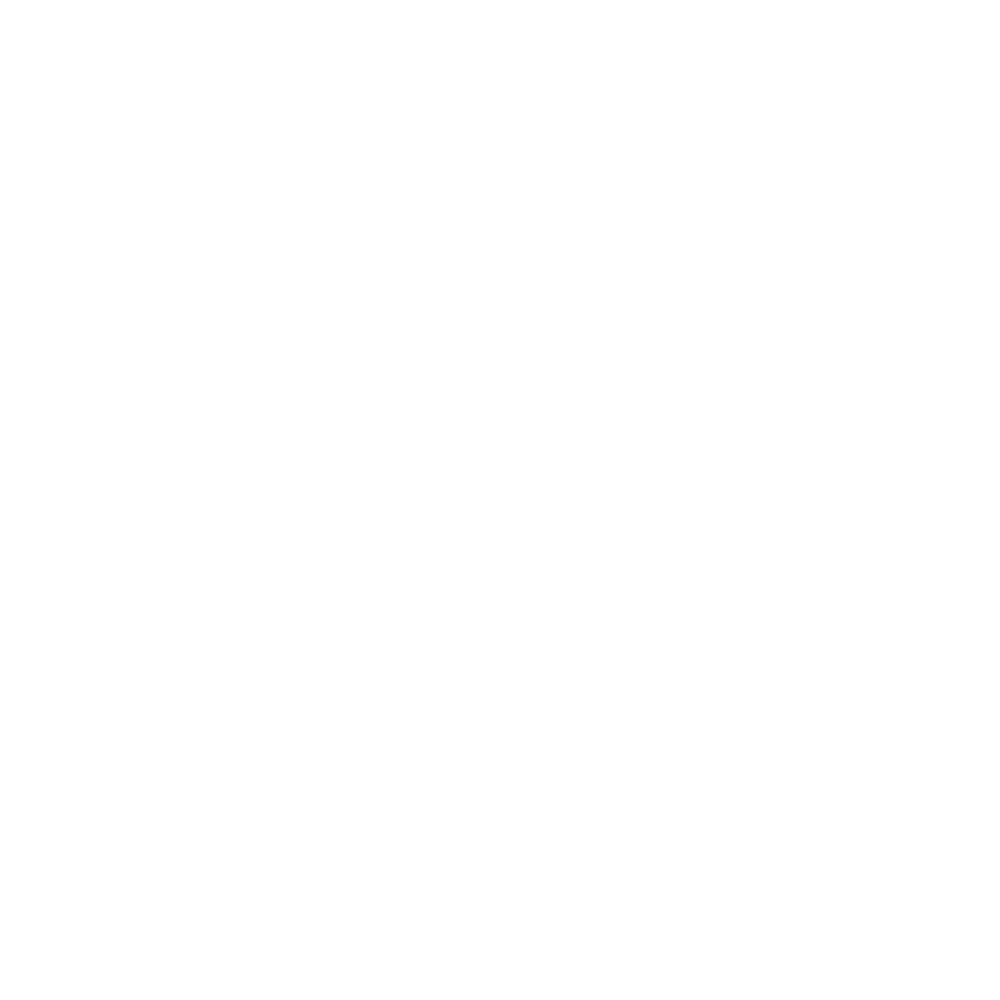

RRuntimeError: Error in geom_sf(color = NA) : 
ℹ Error occurred in the 1st layer.
Caused by error in `compute_layer()`:
! `stat_sf()` requires the following missing aesthetics: geometry.


In [6]:
%%R -i community_board_df -w 1000 -h 1000

community_board_df %>%
  ggplot(aes(fill = `311 Counts`)) + 
  geom_sf(color = NA) + 
  scale_fill_gradient(low="white", high="red") + 
  theme_minimal() +
  labs(
    title = "There is a part of NYC where there are more housing units than people",
    subtitle = "What's up with that?",
    caption = "Source: US Census Bureau"
  ) +
  theme(
    #make title and subitle bigger
    plot.title = element_text(size = 20),
    plot.subtitle = element_text(size = 15),
    # move legend to top
    legend.position = "top"
  )

In [59]:
df_2025[df_2025['Community Board'] == '12 MANHATTAN']['Incident Zip'].value_counts()

Incident Zip
10032    139
10034      7
10033      5
10040      3
Name: count, dtype: int64

In [77]:
df_2025[df_2025['Community Board'] == '12 MANHATTAN']['Location'].value_counts()

Location
(40.83733075391628, -73.94656853762118)     59
(40.83561762599567, -73.9456520072136)      30
(40.836139402067694, -73.946251477162)      21
(40.835829046904706, -73.94581807002287)     7
(40.83665290918615, -73.94678229977103)      3
(40.83588396825875, -73.9458758463922)       3
(40.86655695619762, -73.92753844657459)      3
(40.83501085696898, -73.94525498804433)      3
(40.83415704524157, -73.94482204361711)      3
(40.83417240875407, -73.9483634819345)       2
(40.84946194268086, -73.93034750725323)      1
(40.862154299661306, -73.9272829458812)      1
(40.845936271792255, -73.9324945174274)      1
(40.843817041132596, -73.9367795540281)      1
(40.86748111447652, -73.92626838632344)      1
(40.85123189856867, -73.93940035890009)      1
(40.851476554612354, -73.94012306917718)     1
(40.83722808926937, -73.94422320443937)      1
(40.849412465935345, -73.93022827878026)     1
(40.8639261347363, -73.92971051889944)       1
(40.868075970452765, -73.92511436036561)     1
(40.

In [78]:
df_2025[(df_2025['Community Board'] == '12 MANHATTAN') & 
        (df_2025['Location'] == '(40.83733075391628, -73.94656853762118)')]

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
9,63605500,01/02/2025 09:55:04 PM,01/03/2025 08:52:09 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
22,63661108,01/06/2025 08:44:53 AM,01/07/2025 12:06:59 AM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
34,63664508,01/07/2025 08:40:47 AM,01/08/2025 12:32:00 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
39,63673803,01/07/2025 06:42:06 PM,01/08/2025 12:32:04 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
42,63684835,01/08/2025 08:42:35 AM,01/08/2025 12:32:08 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
48,63678494,01/08/2025 06:26:12 PM,01/09/2025 01:28:32 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
56,63695325,01/09/2025 05:50:43 PM,01/10/2025 01:21:49 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
58,63714043,01/10/2025 08:35:08 AM,01/10/2025 01:21:53 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
65,63714130,01/10/2025 07:52:02 PM,01/11/2025 08:51:41 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
66,63720087,01/10/2025 08:05:23 PM,01/11/2025 08:51:47 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"


In [64]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import ast

# Assuming df_2025 is your DataFrame and it already exists
# Create a subset of the data for Community Board 12 in Manhattan
cb12_data = df_2025[df_2025['Community Board'] == '12 MANHATTAN']

# Get the location value counts
location_counts = cb12_data['Location'].value_counts()

# Convert the location_counts Series to a DataFrame
# The index contains the location strings like "(40.837, -73.946)"
map_data = []

for location_str, count in location_counts.items():
    # Parse the location string into coordinates
    # Convert string representation of tuple to actual coordinates
    try:
        # If the location is already a tuple
        if isinstance(location_str, tuple):
            lat, lon = location_str
        # If the location is a string representation of a tuple
        else:
            # Remove parentheses and split by comma
            coords = location_str.strip('()').split(',')
            lat = float(coords[0].strip())
            lon = float(coords[1].strip())
        
        map_data.append({'lat': lat, 'lon': lon, 'count': count})
    except:
        # Skip invalid locations
        continue

# Create a DataFrame from the parsed data
map_df = pd.DataFrame(map_data)

# Create a base map centered at the mean of coordinates
center_lat = map_df['lat'].mean()
center_lon = map_df['lon'].mean()
mymap = folium.Map(location=[center_lat, center_lon], zoom_start=14)

# Get max count for scaling
max_count = map_df['count'].max()

# Add circle markers with size and color based on count
for idx, row in map_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(5, row['count']/3),  # Adjust divisor as needed
        popup=f"Count: {row['count']}",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=min(0.2 + (row['count'] / max_count) * 0.8, 0.95),
        opacity=0.8
    ).add_to(mymap)

# Add heatmap layer
heat_data = [[row['lat'], row['lon'], row['count']] for idx, row in map_df.iterrows()]
HeatMap(heat_data).add_to(mymap)

# Save the map
mymap.save('manhattan_cb12_heatmap.html')

# If in a Jupyter notebook, display the map
display(mymap)

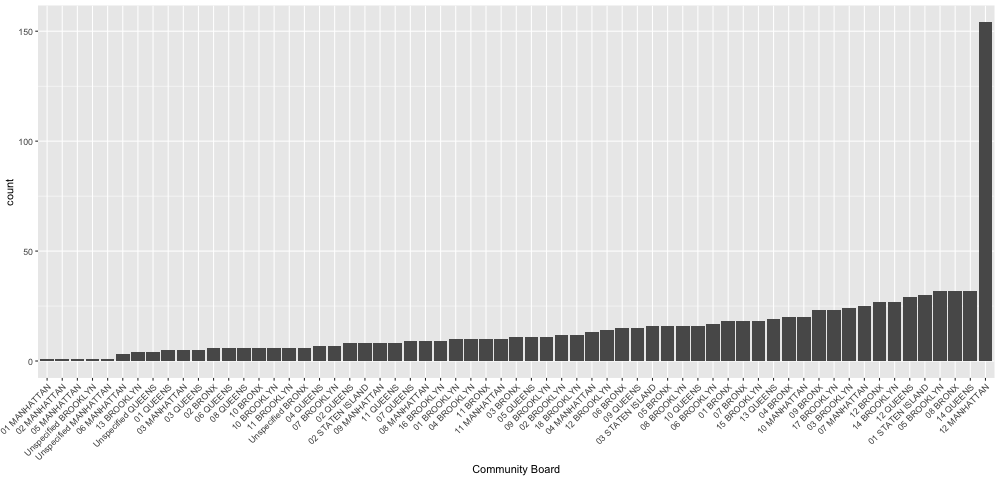

In [54]:
%%R -i df_2025 -w 1000
# Count the frequencies
counts <- as.data.frame(table(df_2025$`Community Board`))
names(counts) <- c("Community_Board", "Freq")

# Sort the counts
counts <- counts[order(counts$Freq),]

# Convert to factor with ordered levels
df_2025$`Community Board` <- factor(df_2025$`Community Board`, 
                                   levels = counts$Community_Board)

# Now plot with the ordered factor
ggplot(df_2025, aes(x=`Community Board`)) +
    geom_bar() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

### January - March 2024

In [50]:
df_2024 = pd.read_csv('docs/311_poop_2024.csv')

In [8]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      788 non-null    int64  
 1   Created Date                    788 non-null    object 
 2   Closed Date                     788 non-null    object 
 3   Agency                          788 non-null    object 
 4   Agency Name                     788 non-null    object 
 5   Complaint Type                  788 non-null    object 
 6   Descriptor                      788 non-null    object 
 7   Location Type                   788 non-null    object 
 8   Incident Zip                    786 non-null    float64
 9   Incident Address                788 non-null    object 
 10  Street Name                     788 non-null    object 
 11  Cross Street 1                  785 non-null    object 
 12  Cross Street 2                  785 

In [30]:
pd.set_option('display.max_rows', None)
df_2024['Community Board'].value_counts()

Community Board
12 QUEENS                    39
07 BRONX                     30
05 BROOKLYN                  29
01 QUEENS                    23
01 BROOKLYN                  23
11 MANHATTAN                 20
05 QUEENS                    20
03 STATEN ISLAND             20
17 BROOKLYN                  19
12 BRONX                     19
09 BRONX                     19
01 STATEN ISLAND             19
06 BRONX                     17
07 BROOKLYN                  17
07 QUEENS                    16
12 MANHATTAN                 16
13 QUEENS                    16
03 BROOKLYN                  16
10 QUEENS                    15
18 BROOKLYN                  15
14 BROOKLYN                  15
09 MANHATTAN                 15
10 MANHATTAN                 14
02 QUEENS                    13
09 BROOKLYN                  13
03 BRONX                     13
15 BROOKLYN                  13
02 STATEN ISLAND             12
02 BROOKLYN                  12
08 BRONX                     12
14 QUEENS               

In [55]:
952-788

164

In [32]:
# percent increase from the same period in 2024 to 2025
(952-788)/788

0.20812182741116753

In [34]:
df_2024['Community Board'].nunique()

63

**--> In 2024, there were complaints from every community district (59 districts + 4 unspecified).**

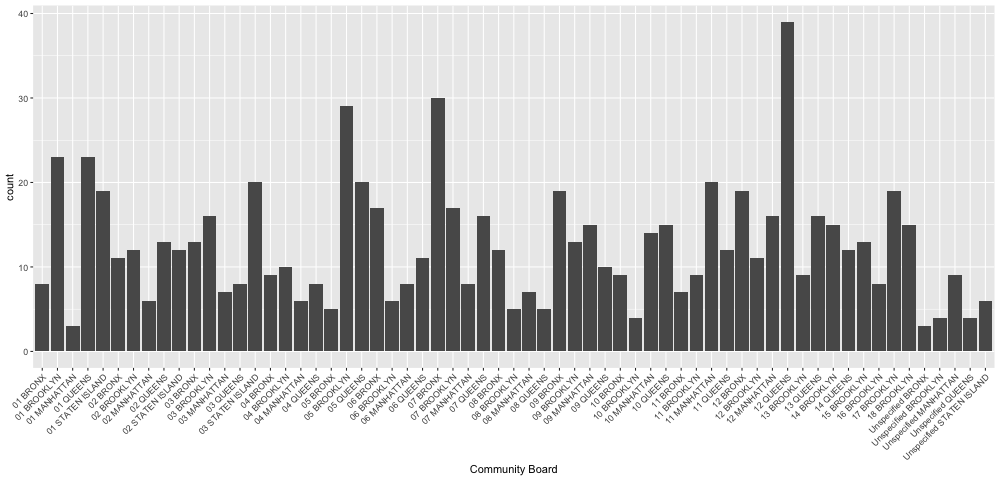

In [48]:
%%R -i df_2024 -w 1000

ggplot(df_2024, aes(x=`Community Board`)) +
    geom_bar() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

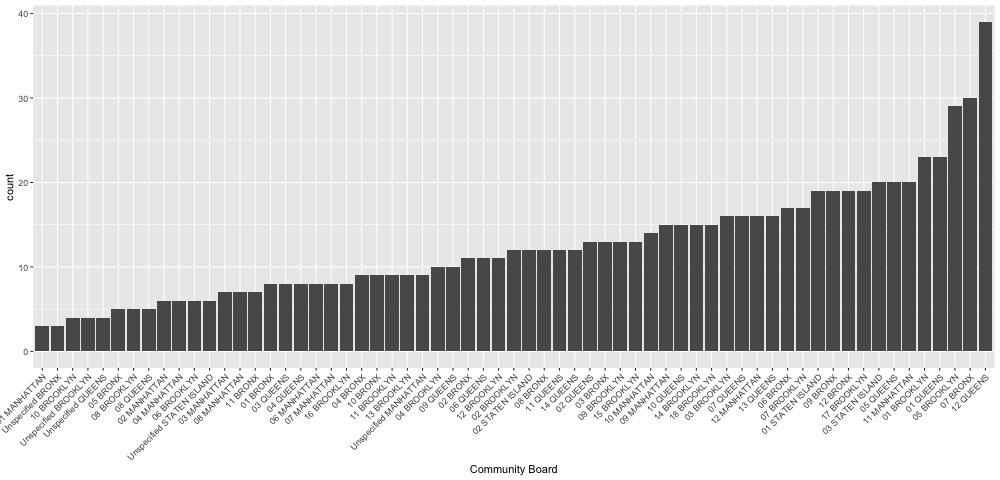

In [53]:
%%R -i df_2024 -w 1000
# Count the frequencies
counts <- as.data.frame(table(df_2024$`Community Board`))
names(counts) <- c("Community_Board", "Freq")

# Sort the counts
counts <- counts[order(counts$Freq),]

# Convert to factor with ordered levels
df_2024$`Community Board` <- factor(df_2024$`Community Board`, 
                                   levels = counts$Community_Board)

# Now plot with the ordered factor
ggplot(df_2024, aes(x=`Community Board`)) +
    geom_bar() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

### January - March 2023

In [40]:
df_2023 = pd.read_csv('docs/311_poop_2023.csv')

In [41]:
df_2022 = pd.read_csv('docs/311_poop_2022.csv')

In [42]:
df_2021 = pd.read_csv('docs/311_poop_2021.csv')

In [43]:
df_2020 = pd.read_csv('docs/311_poop_2020.csv')

In [44]:
df_2019 = pd.read_csv('docs/311_poop_2019.csv')

In [45]:
df_2018 = pd.read_csv('docs/311_poop_2018.csv')

In [46]:
df_2017 = pd.read_csv('docs/311_poop_2017.csv')

In [47]:
df_2016 = pd.read_csv('docs/311_poop_2016.csv')

In [48]:
df_2015 = pd.read_csv('docs/311_poop_2015.csv')

In [19]:
!pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


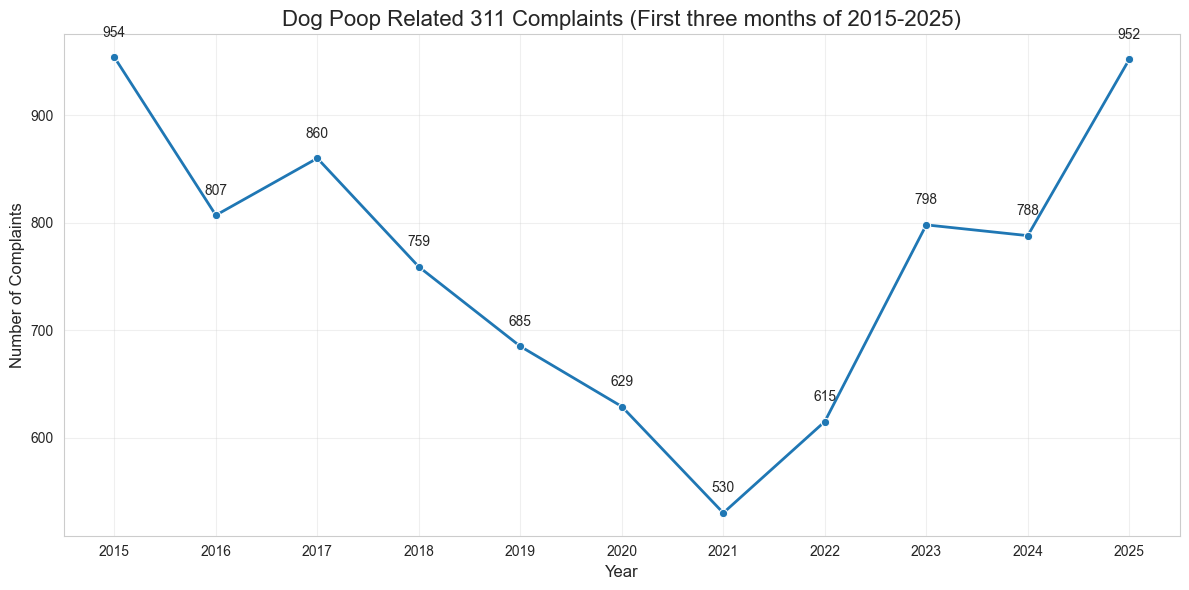

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of your dataframes
dataframes = [df_2015, df_2016, df_2017, df_2018, df_2019, 
              df_2020, df_2021, df_2022, df_2023, df_2024, df_2025]

# Create a list of years
years = list(range(2015, 2026))

# Count the number of rows in each dataframe
counts = [len(df) for df in dataframes]

# Create a DataFrame to store the years and counts
trend_data = pd.DataFrame({
    'Year': years,
    'Number of Complaints': counts
})

# Set the style
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='Year', y='Number of Complaints', marker='o', linewidth=2)

# Add title and labels
plt.title('Dog Poop Related 311 Complaints (First three months of 2015-2025)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)

# Add data labels
for x, y in zip(years, counts):
    plt.text(x, y + max(counts)*0.02, f'{y:,}', ha='center')

# Improve the appearance
plt.tight_layout()
plt.xticks(years)
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

In [53]:
trend_data.to_csv('docs/YOY_Sum.csv', index=False)